In [1]:
"""
BiLSTM Model: Masked Nucleotide Prediction (M Only)
----------------------------------------------------
Dataset: Salmonella Typhimurium (11 genomes)

Input files:
- train_m.txt : 10 genomes, masked sequences (inputs)
- train.txt   : 10 genomes, raw sequences (targets)
- test_m.txt  : Salmonella 11, masked sequences (inputs)
- test.txt    : Salmonella 11, raw sequences (targets)

Masking Strategy:
- Pattern: i % 5 == (i // 5) % 5 (same as transformer)
- M only masking at 20%, Seed 42 for reproducibility

Model Architecture (BiLSTM):
- 5-mer tokenisation (1027 tokens)
- Bidirectional LSTM processes sequence in both directions
- Captures long range dependencies via recurrent hidden state
- Embedding dim : 128
- Hidden dim    : 256 (128 each direction)
- Num layers    : 2
- Window size   : 128 (5-mers)

Data Split:
- 85% of training data for training
- 15% of training data for validation (early stopping)
- Test set (Salmonella 11) completely untouched until evaluation

Training:
- Optimiser : AdamW
- Loss      : Cross Entropy (masked positions only)
- Early stopping patience: 2
- Device    : CUDA if available, else CPU
"""


'\nBiLSTM Model: Masked Nucleotide Prediction (M Only)\n----------------------------------------------------\nDataset: Salmonella Typhimurium (11 genomes)\n\nInput files:\n- train_m.txt : 10 genomes, masked sequences (inputs)\n- train.txt   : 10 genomes, raw sequences (targets)\n- test_m.txt  : Salmonella 11, masked sequences (inputs)\n- test.txt    : Salmonella 11, raw sequences (targets)\n\nMasking Strategy:\n- Pattern: i % 5 == (i // 5) % 5 (same as transformer)\n- M only masking at 20%, Seed 42 for reproducibility\n\nModel Architecture (BiLSTM):\n- 5-mer tokenisation (1027 tokens)\n- Bidirectional LSTM processes sequence in both directions\n- Captures long range dependencies via recurrent hidden state\n- Embedding dim : 128\n- Hidden dim    : 256 (128 each direction)\n- Num layers    : 2\n- Window size   : 128 (5-mers)\n\nData Split:\n- 85% of training data for training\n- 15% of training data for validation (early stopping)\n- Test set (Salmonella 11) completely untouched until ev

Step 1 - Imports

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import itertools
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# ── Reproducibility seeds ─────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
print(f"  Seed set to {SEED}")


  Seed set to 42


Step 2 - Hyperparameters

In [3]:
# ── Build 5-mer vocabulary ────────────────────────────────────────────────────
bases    = ["A", "C", "G", "T"]
kmers    = ["".join(k) for k in itertools.product(bases, repeat=5)]
kmer2idx = {kmer: idx for idx, kmer in enumerate(kmers)}
kmer2idx["MASK"] = 1024
kmer2idx["PAD"]  = 1025
kmer2idx["UNK"]  = 1026
VOCAB      = kmer2idx
VOCAB_SIZE = len(VOCAB)  # 1027

# ── Windowing ─────────────────────────────────────────────────────────────────
WINDOW_SIZE = 128
STRIDE      = 64

# ── Model Architecture ────────────────────────────────────────────────────────
EMBED_DIM   = 128
HIDDEN_DIM  = 256   # 128 per direction
NUM_LAYERS  = 2     # stacked BiLSTM layers
DROPOUT     = 0.1

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE    = 64
EPOCHS        = 20
LEARNING_RATE = 3e-4

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  Vocabulary size : {VOCAB_SIZE}")
print(f"  Window size     : {WINDOW_SIZE}")
print(f"  Device          : {DEVICE}")


  Vocabulary size : 1027
  Window size     : 128
  Device          : cuda


Step 3 - Dataset

In [4]:
class DNADataset(Dataset):
    def __init__(self, masked_path, original_path, window_size=WINDOW_SIZE, stride=STRIDE):
        self.windows_input  = []
        self.windows_target = []

        masked_seqs   = open(masked_path,   "r").readlines()
        original_seqs = open(original_path, "r").readlines()

        for masked_seq, original_seq in zip(masked_seqs, original_seqs):
            masked_seq   = masked_seq.strip().upper()
            original_seq = original_seq.strip().upper()

            masked_kmers = []
            for i in range(0, len(masked_seq) - 4, 1):
                kmer = masked_seq[i:i+5]
                if "M" in kmer:
                    masked_kmers.append(VOCAB["MASK"])
                elif "N" in kmer:
                    masked_kmers.append(VOCAB["UNK"])
                else:
                    masked_kmers.append(VOCAB.get(kmer, VOCAB["UNK"]))

            original_kmers = []
            for i in range(0, len(original_seq) - 4, 1):
                kmer = original_seq[i:i+5]
                if "N" in kmer:
                    original_kmers.append(VOCAB["UNK"])
                else:
                    original_kmers.append(VOCAB.get(kmer, VOCAB["UNK"]))

            for start in range(0, len(original_kmers) - window_size, stride):
                inp = masked_kmers  [start : start + window_size]
                tgt = original_kmers[start : start + window_size]
                self.windows_input.append(torch.tensor(inp, dtype=torch.long))
                self.windows_target.append(torch.tensor(tgt, dtype=torch.long))

    def __len__(self):
        return len(self.windows_input)

    def __getitem__(self, idx):
        return self.windows_input[idx], self.windows_target[idx]


# ── Load full training set then split 85/15 into train/val ───────────────────
full_train   = DNADataset("train_m.txt", "train.txt")
test_dataset = DNADataset("test_m.txt",  "test.txt")

train_size = int(0.85 * len(full_train))
val_size   = len(full_train) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"  Total train windows  : {len(full_train):,}")
print(f"  Train split (85%)    : {len(train_dataset):,}")
print(f"  Val split   (15%)    : {len(val_dataset):,}")
print(f"  Test windows         : {len(test_dataset):,}")


  Total train windows  : 775,244
  Train split (85%)    : 658,957
  Val split   (15%)    : 116,287
  Test windows         : 77,075


Step 4 - BiLSTM Model

In [5]:
class BiLSTMDNAModel(nn.Module):
    def __init__(self):
        super().__init__()

        # 5-mer embedding
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=VOCAB["PAD"])

        # Bidirectional LSTM
        # bidirectional=True means each layer has 2 LSTMs (forward + backward)
        # hidden size per direction = HIDDEN_DIM // 2 so total output = HIDDEN_DIM
        self.bilstm = nn.LSTM(
            input_size    = EMBED_DIM,
            hidden_size   = HIDDEN_DIM // 2,  # 128 per direction
            num_layers    = NUM_LAYERS,
            batch_first   = True,
            bidirectional = True,
            dropout       = DROPOUT if NUM_LAYERS > 1 else 0.0
        )

        self.dropout      = nn.Dropout(DROPOUT)
        self.norm         = nn.LayerNorm(HIDDEN_DIM)
        self.output_layer = nn.Linear(HIDDEN_DIM, VOCAB_SIZE)

    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x)          # (batch, seq_len, embed_dim)
        x, _ = self.bilstm(x)          # (batch, seq_len, hidden_dim)
        x = self.dropout(x)
        x = self.norm(x)
        x = self.output_layer(x)       # (batch, seq_len, vocab_size)
        return x


model = BiLSTMDNAModel().to(DEVICE)
print(model)
print(f"\n  Total parameters: {sum(p.numel() for p in model.parameters()):,}")


BiLSTMDNAModel(
  (embedding): Embedding(1027, 128, padding_idx=1025)
  (bilstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=256, out_features=1027, bias=True)
)

  Total parameters: 1,055,363


Step 5 - Training

In [6]:
PATIENCE         = 2
best_loss        = float("inf")
patience_counter = 0

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0; total_correct = 0; total_masked = 0
    for input_kmers, target_kmers in loader:
        input_kmers  = input_kmers.to(DEVICE)
        target_kmers = target_kmers.to(DEVICE)
        optimizer.zero_grad()
        output         = model(input_kmers)
        mask           = (input_kmers == VOCAB["MASK"])
        masked_output  = output[mask]
        masked_targets = target_kmers[mask]
        loss           = criterion(masked_output, masked_targets)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item()
        predictions    = masked_output.argmax(dim=-1)
        total_correct += (predictions == masked_targets).sum().item()
        total_masked  += mask.sum().item()
    return total_loss / len(loader), total_correct / total_masked * 100


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0; total_correct = 0; total_masked = 0
    with torch.no_grad():
        for input_kmers, target_kmers in loader:
            input_kmers  = input_kmers.to(DEVICE)
            target_kmers = target_kmers.to(DEVICE)
            output         = model(input_kmers)
            mask           = (input_kmers == VOCAB["MASK"])
            masked_output  = output[mask]
            masked_targets = target_kmers[mask]
            loss           = criterion(masked_output, masked_targets)
            total_loss    += loss.item()
            predictions    = masked_output.argmax(dim=-1)
            total_correct += (predictions == masked_targets).sum().item()
            total_masked  += mask.sum().item()
    return total_loss / len(loader), total_correct / total_masked * 100


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    print(f"  Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    scheduler.step(val_loss)
    if val_loss < best_loss:
        best_loss        = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "bilstm_best_m.pth")
        print(f"  --> Best model saved at epoch {epoch}")
    else:
        patience_counter += 1
        print(f"  --> No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"  Early stopping triggered at epoch {epoch}!")
            break


  Epoch 01/20 | Train Loss: 1.9738 | Train Acc: 29.71% | Val Loss: 1.6361 | Val Acc: 33.66%
  --> Best model saved at epoch 1
  Epoch 02/20 | Train Loss: 1.6429 | Train Acc: 33.41% | Val Loss: 1.6034 | Val Acc: 35.33%
  --> Best model saved at epoch 2
  Epoch 03/20 | Train Loss: 1.6114 | Train Acc: 34.95% | Val Loss: 1.5907 | Val Acc: 35.92%
  --> Best model saved at epoch 3
  Epoch 04/20 | Train Loss: 1.5909 | Train Acc: 35.96% | Val Loss: 1.5710 | Val Acc: 36.94%
  --> Best model saved at epoch 4
  Epoch 05/20 | Train Loss: 1.5785 | Train Acc: 36.55% | Val Loss: 1.5627 | Val Acc: 37.30%
  --> Best model saved at epoch 5
  Epoch 06/20 | Train Loss: 1.5696 | Train Acc: 36.95% | Val Loss: 1.5551 | Val Acc: 37.60%
  --> Best model saved at epoch 6
  Epoch 07/20 | Train Loss: 1.5637 | Train Acc: 37.24% | Val Loss: 1.5524 | Val Acc: 37.72%
  --> Best model saved at epoch 7
  Epoch 08/20 | Train Loss: 1.5597 | Train Acc: 37.42% | Val Loss: 1.5490 | Val Acc: 37.93%
  --> Best model saved at 

Step 6 - Evaluation

  EVALUATION RESULTS — Test Set (Unseen Genome)
  Test Loss                        : 1.5376
  Test Accuracy (5-mer token)       : 38.42%
  Test Accuracy (single nucleotide) : 85.24%
  Total masked positions            : 8,287,104

  Classification Report (per nucleotide):
              precision    recall  f1-score   support

           A     0.8571    0.8379    0.8474   1983909
           T     0.8435    0.8447    0.8441   1982120
           G     0.8537    0.8624    0.8580   2158096
           C     0.8549    0.8627    0.8588   2162979

    accuracy                         0.8524   8287104
   macro avg     0.8523    0.8519    0.8521   8287104
weighted avg     0.8524    0.8524    0.8523   8287104



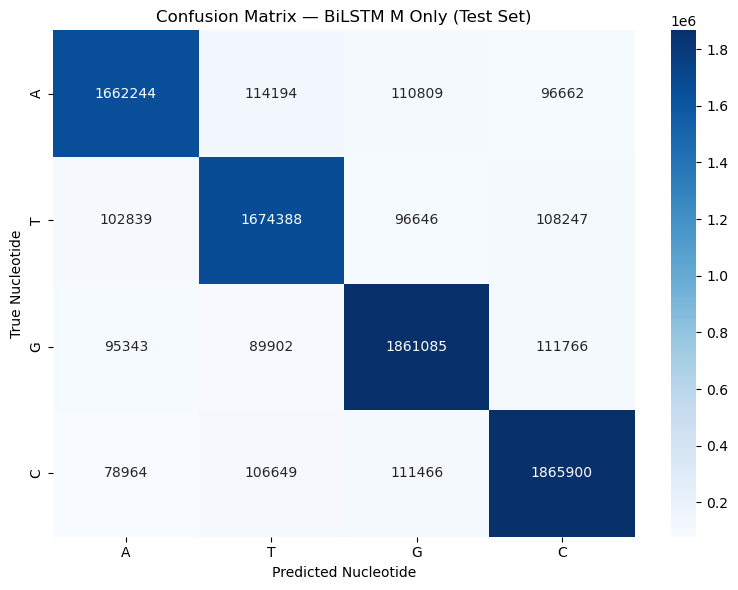

  Confusion matrix saved as confusion_matrix_bilstm_m.png


In [7]:
model.load_state_dict(torch.load("bilstm_best_m.pth", map_location=DEVICE))
model.eval()

all_preds   = []
all_targets = []
total_correct = 0
total_masked  = 0
total_loss    = 0

idx2kmer = {v: k for k, v in VOCAB.items() if len(k) == 5}
def kmer_to_nuc(idx):
    kmer = idx2kmer.get(idx, "N")
    return kmer[0] if kmer != "N" else "N"

with torch.no_grad():
    for input_kmers, target_kmers in test_loader:
        input_kmers  = input_kmers.to(DEVICE)
        target_kmers = target_kmers.to(DEVICE)
        output         = model(input_kmers)
        mask           = (input_kmers == VOCAB["MASK"])
        masked_output  = output[mask]
        masked_targets = target_kmers[mask]
        loss           = criterion(masked_output, masked_targets)
        total_loss    += loss.item()
        predictions    = masked_output.argmax(dim=-1)
        total_correct += (predictions == masked_targets).sum().item()   # 5-mer match
        total_masked  += mask.sum().item()
        all_preds.extend  ([kmer_to_nuc(p.item()) for p in predictions])
        all_targets.extend([kmer_to_nuc(t.item()) for t in masked_targets])

test_accuracy_5mer = total_correct / total_masked * 100
test_loss           = total_loss / len(test_loader)

nucleotide_correct  = sum(1 for p, t in zip(all_preds, all_targets) if p == t)
nucleotide_total    = len(all_targets)
test_accuracy_nuc   = nucleotide_correct / nucleotide_total * 100

print("=" * 60)
print("  EVALUATION RESULTS — Test Set (Unseen Genome)")
print("=" * 60)
print(f"  Test Loss                        : {test_loss:.4f}")
print(f"  Test Accuracy (5-mer token)       : {test_accuracy_5mer:.2f}%")
print(f"  Test Accuracy (single nucleotide) : {test_accuracy_nuc:.2f}%")
print(f"  Total masked positions            : {total_masked:,}")
print("=" * 60)

print("\n  Classification Report (per nucleotide):")
print(classification_report(all_targets, all_preds, labels=["A", "T", "G", "C"], digits=4))

labels = ["A", "T", "G", "C"]
cm = confusion_matrix(all_targets, all_preds, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — BiLSTM M Only (Test Set)")
plt.xlabel("Predicted Nucleotide")
plt.ylabel("True Nucleotide")
plt.tight_layout()
plt.savefig("confusion_matrix_bilstm_m.png", dpi=150)
plt.show()
print("  Confusion matrix saved as confusion_matrix_bilstm_m.png")

Step 7 - ROC Curve

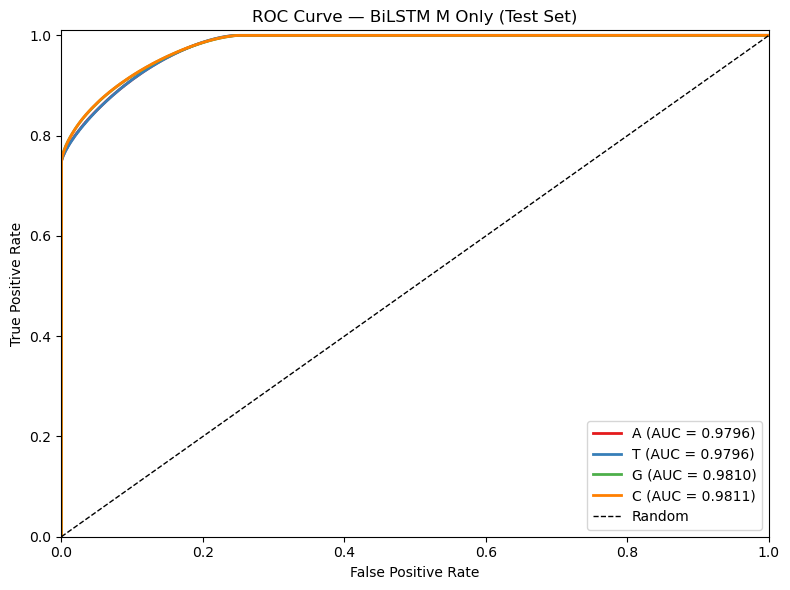

  ROC curve saved as roc_curve_bilstm_m.png


In [8]:
model.eval()
all_probs  = []
all_true   = []
nuc_labels = ["A", "T", "G", "C"]
nuc_to_idx = {"A": 0, "T": 1, "G": 2, "C": 3}

with torch.no_grad():
    for input_kmers, target_kmers in test_loader:
        input_kmers  = input_kmers.to(DEVICE)
        target_kmers = target_kmers.to(DEVICE)
        output       = model(input_kmers)
        mask         = (input_kmers == VOCAB["MASK"])
        masked_output  = output[mask]
        masked_targets = target_kmers[mask]

        probs = torch.softmax(masked_output, dim=-1).cpu().numpy()
        tgts  = masked_targets.cpu().numpy()

        nuc_probs = np.zeros((probs.shape[0], 4))
        for nuc_i, nuc in enumerate(nuc_labels):
            kmer_indices = [v for k, v in VOCAB.items() if len(k) == 5 and k[0] == nuc]
            nuc_probs[:, nuc_i] = probs[:, kmer_indices].sum(axis=1)

        true_nucs = [kmer_to_nuc(t) for t in tgts]
        true_idxs = [nuc_to_idx.get(n, 0) for n in true_nucs]

        all_probs.extend(nuc_probs.tolist())
        all_true.extend(true_idxs)

all_probs    = np.array(all_probs)
all_true     = np.array(all_true)
all_true_bin = label_binarize(all_true, classes=[0, 1, 2, 3])

colors = ["#e41a1c", "#377eb8", "#4daf4a", "#ff7f00"]
plt.figure(figsize=(8, 6))

for i, (nuc, color) in enumerate(zip(nuc_labels, colors)):
    fpr, tpr, _ = roc_curve(all_true_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{nuc} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — BiLSTM M Only (Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_bilstm_m.png", dpi=150)
plt.show()
print("  ROC curve saved as roc_curve_bilstm_m.png")
